# B13 Paper Figure Assembly

This notebook uses the same plotting functions as `tools/case_study/assemble_paper_figures.py`, but exposes them one figure at a time for interactive editing in Jupyter.


In [19]:
from pathlib import Path
import sys
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "tools" / "case_study" / "assemble_paper_figures.py").exists():
            return candidate
    raise FileNotFoundError("could not locate repo root from the current working directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tools.case_study import assemble_paper_figures as apf

# Match the CLI paper-figure styling inside Jupyter as well.
apf.apply_matplotlib_style()


In [20]:
run_id = "router_lora_case_v1"
config_path = None
figures_dir_override = None
storyline_path_override = None

# For the plateau-style Fig. 4, make sure the run-scoped B10 sweep here includes
# num_loras=1..8 and cache_budget=8192 or larger.
sweeps_root = REPO_ROOT / "artifacts" / "case_study" / run_id / "sweeps"


In [21]:
paths = apf.resolve_b13_paths(
    config_path=config_path,
    run_id=run_id,
    figures_dir=str(figures_dir_override) if figures_dir_override else None,
    sweeps_dir=str(sweeps_root),
    storyline_path=str(storyline_path_override) if storyline_path_override else None,
)

apf.ensure_paths_exist(
    [
        paths.popularity_path,
        paths.reuse_path,
        paths.cache_curve_path,
        paths.per_request_miss_path,
        paths.tail_breakdown_path,
        paths.num_loras_path,
    ]
)

print(f"run_id: {paths.run_id}")
print(f"sweeps_root: {paths.sweeps_root}")
print(f"figures_dir: {paths.figures_dir}")
print(f"storyline_path: {paths.storyline_path}")


run_id: router_lora_case_v1
sweeps_root: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/sweeps
figures_dir: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures
storyline_path: /home/shufan/LightLLM-integrate-to-SLoRA/notes/storyline_case_study.md


In [22]:
def preview_and_save(plot_fn, *plot_args):
    fig, record = plot_fn(*plot_args)
    display(fig)
    apf.save_figure(fig, record.output_path)
    print(f"saved: {record.output_path}")
    print(f"claim: {record.claim}")
    print(f"caption: {record.caption}")
    return record


## Draw Figures

Run each cell after editing the plotting code or the inputs you want to inspect.


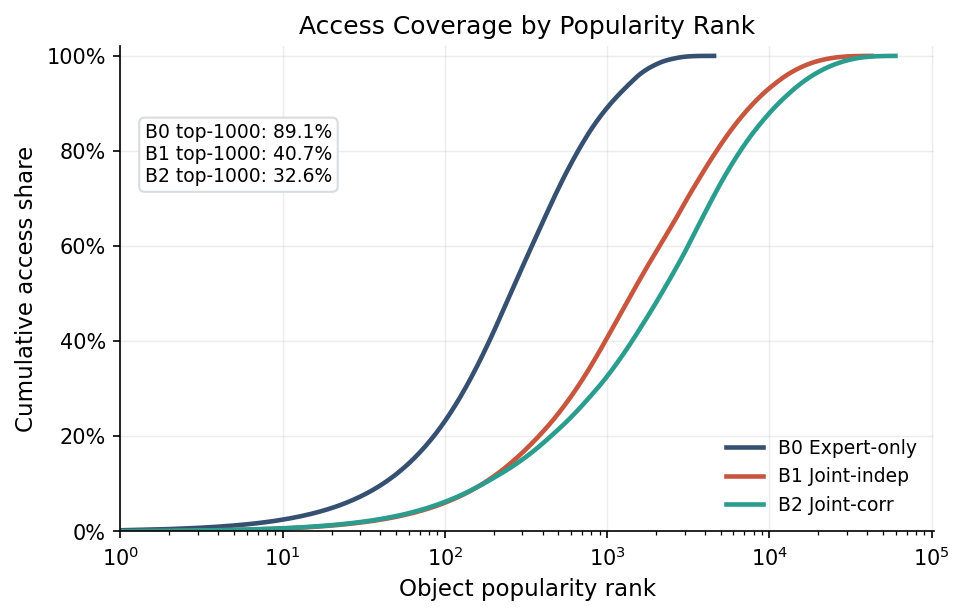

saved: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/fig1_popularity_rank.pdf
claim: joint access is more fragmented than expert-only access
caption: Cumulative access share versus object popularity rank. The expert-only stream concentrates 89.1% of accesses in the top 1000 objects, while the joint stream falls to 40.7% in B1 and 32.6% in B2, indicating a much flatter and more fragmented popularity profile once adapters enter the access key.


In [23]:
fig1_record = preview_and_save(
    apf.plot_fig1_popularity_rank,
    paths.popularity_path,
    paths.figures_dir / "fig1_popularity_rank.pdf",
)


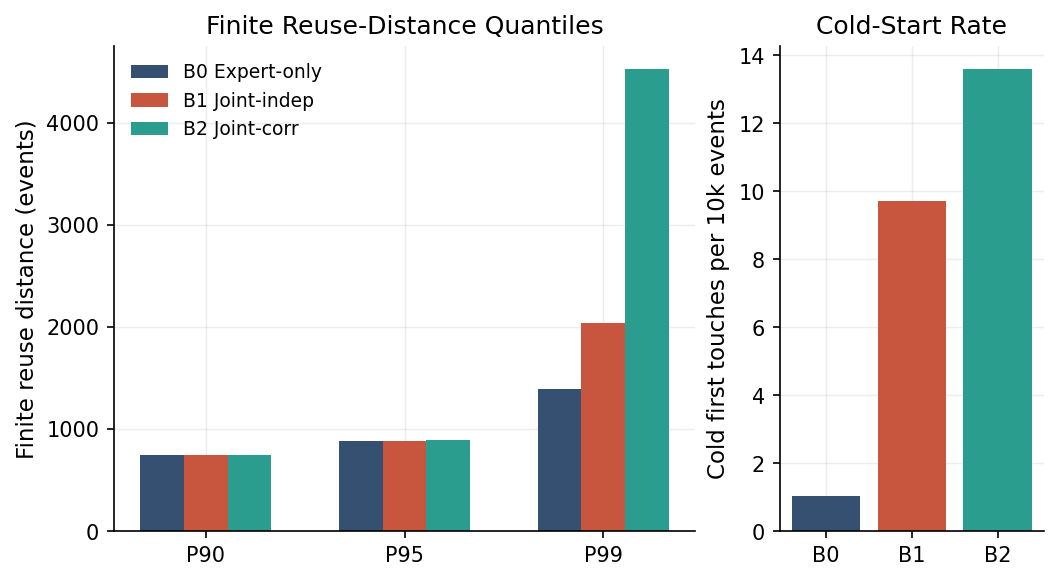

saved: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/fig2_reuse_distance.pdf
claim: joint objects have worse temporal locality
caption: Joint keys worsen temporal locality in both tail reuse distance and cold-start rate. The finite P99 reuse distance rises from 1,393 events in B0 to 2,041 in B1 and 4,521 in B2, while cold first touches rise from 1.0 to 9.7 and 13.6 per 10k events.


In [24]:
fig2_record = preview_and_save(
    apf.plot_fig2_reuse_distance,
    paths.reuse_path,
    paths.figures_dir / "fig2_reuse_distance.pdf",
)


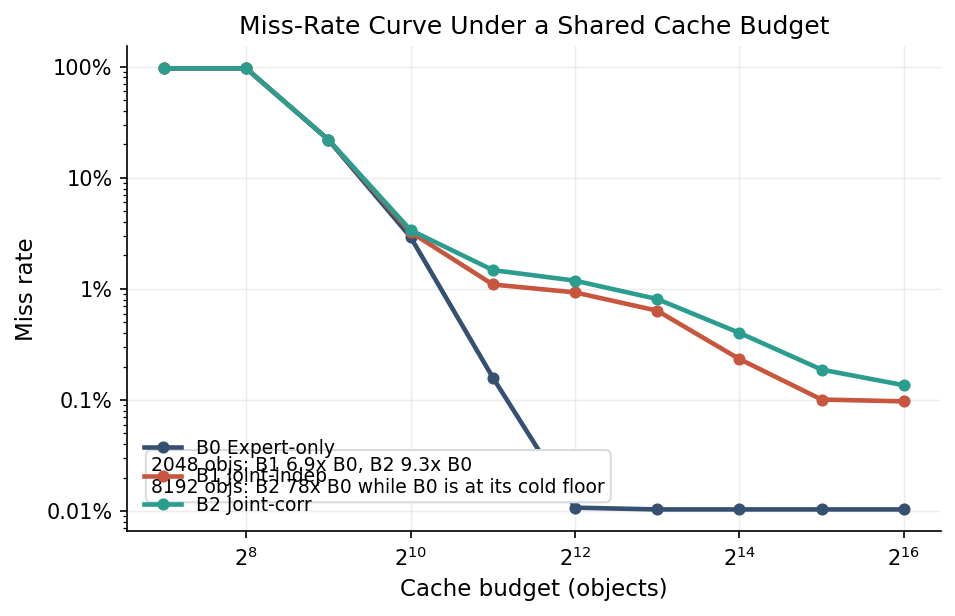

saved: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/fig3_cache_curve.pdf
claim: joint modeling amplifies misses under the same budget
caption: Cache replay under a shared LRU budget shows that joint modeling amplifies misses after the expert-only condition reaches its locality scale. At 2048 objects, miss rate is 0.00159 in B0 versus 0.01095 in B1 and 0.01476 in B2 (6.9x and 9.3x worse than B0).


In [25]:
fig3_record = preview_and_save(
    apf.plot_fig3_cache_curve,
    paths.cache_curve_path,
    paths.figures_dir / "fig3_cache_curve.pdf",
)


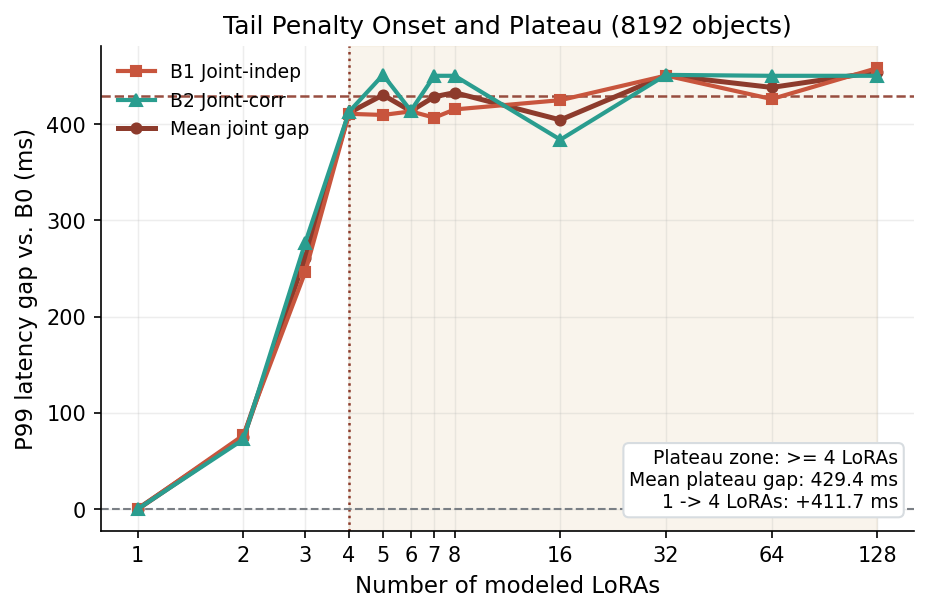

saved: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/fig4_num_loras_vs_p99.pdf
claim: tail penalty rises quickly from the single-LoRA regime and then plateaus
caption: At the 8192-object slice, the joint P99 penalty rises from 0.0 ms at 1 LoRA to 411.7 ms at 4 LoRAs, then stays on a broad plateau around 429.4 ms for >= 4 LoRAs. B1 and B2 plateau near 423.9 ms and 434.9 ms, respectively.


In [26]:
fig4_record = preview_and_save(
    apf.plot_fig4_num_loras_vs_p99,
    paths.num_loras_path,
    paths.figures_dir / "fig4_num_loras_vs_p99.pdf",
)


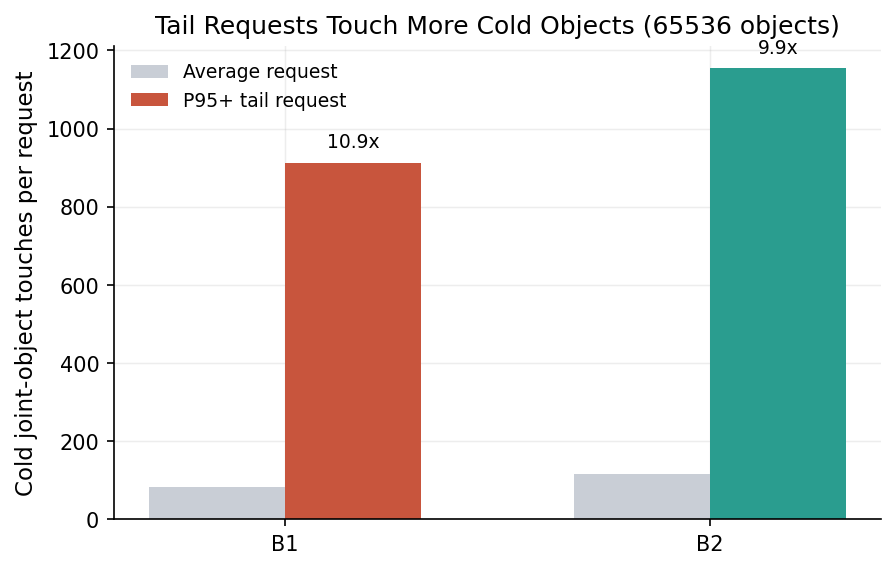

saved: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/fig5_tail_breakdown.pdf
claim: tail requests touch more cold joint objects than average requests
caption: At the 65536-object cold-miss floor, an average request touches 83.6 cold joint objects in B1 and 116.8 in B2, but a P95+ tail request touches 912.8 and 1154.0, roughly 10.9x and 9.9x more than average.


In [27]:
fig5_record = preview_and_save(
    apf.plot_fig5_tail_breakdown,
    paths.cache_curve_path,
    paths.per_request_miss_path,
    paths.tail_breakdown_path,
    paths.figures_dir / "fig5_tail_breakdown.pdf",
)


In [28]:
figure_records = [
    fig1_record,
    fig2_record,
    fig3_record,
    fig4_record,
    fig5_record,
]

manifest_path = paths.figures_dir / "figure_manifest.md"
apf.write_manifest(manifest_path, paths.run_id, figure_records)
apf.write_storyline(paths.storyline_path, paths.run_id, figure_records)

print(f"manifest: {manifest_path}")
print(f"storyline: {paths.storyline_path}")


manifest: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/figure_manifest.md
storyline: /home/shufan/LightLLM-integrate-to-SLoRA/notes/storyline_case_study.md


## Full Batch Rebuild

If you do not need to step through figures individually, this cell regenerates all five PDFs, the manifest, and the storyline in one call.


In [29]:
records, manifest_path, storyline_path = apf.assemble_paper_figures(
    config_path=config_path,
    run_id=run_id,
    figures_dir=str(figures_dir_override) if figures_dir_override else None,
    sweeps_dir=str(sweeps_root),
    storyline_path=str(storyline_path_override) if storyline_path_override else None,
)

print(f"figures: {len(records)}")
print(f"manifest: {manifest_path}")
print(f"storyline: {storyline_path}")


figures: 5
manifest: /home/shufan/LightLLM-integrate-to-SLoRA/artifacts/case_study/router_lora_case_v1/figures/figure_manifest.md
storyline: /home/shufan/LightLLM-integrate-to-SLoRA/notes/storyline_case_study.md
